# Parameter-Based Curve Reconstruction (Leave-One-Out)

> **Authors:** Davide Corso, Marco Soldani  
> **Context:** Analysis of Galvanostatic Electrochemical Impedance Spectroscopy (GEIS) data on Lithium-Ion batteries (LiCoO₂).

This work is based on the research paper: *"Hysteresis Phenomenon in the Electric Parameters of Lithium-Ion Batteries under Temperature Effects"* (Barcellona et al., THERMINIC 2025).

### Dataset Overview
* **Scope:** 5 Epochs (aging states) × 8 Temperatures × 5 SOC levels.
* **Total Data:** 40 unique Nyquist plots.
* **Objective:** Perform a **Leave-One-Out** cross-validation by excluding one specific *Epoch × Temperature* combination. The goal is to train models on the remaining 39 combinations to accurately predict the 40th (unseen) plot.

---

### Project Pipeline
1. **Data Conversion:** Automated transformation from raw MATLAB files (`.mat`) to structured CSV format.
2. **EDA (Exploratory Data Analysis):** Visualizing impedance trends across different temperatures and aging stages.
3. **Leave-One-Out Setup:** Manual or randomized selection of the test set (the "excluded" combination).
4. **Feature Engineering:** Extracting and scaling relevant physical parameters for the ML models.
5. **Multi-Model Benchmarking:** Training and testing 6 different regression models.
6. **Model Selection:** Identifying the best-performing architecture based on error metrics (MAE, RMSE).
7. **Hyperparameter Tuning:** Fine-tuning the best model to improve reconstruction accuracy.
8. **Error Analysis:** Detailed evaluation of residuals and physical consistency of the predictions.
9. **Grid Reconstruction:** Final 40/40 visualization to validate the global performance of the approach.

---

# 1. Setup

In [1]:
import sys
assert sys.version_info >= (3, 5), "Python 3.5+ is required"

# --- STANDARD LIBRARIES ---
import warnings
import time

# --- SCIENTIFIC LIBRARIES ---
import numpy as np
import pandas as pd
import scipy.io

# --- VISUALIZATION ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- MACHINE LEARNING ---
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    BaggingRegressor,
    ExtraTreesRegressor
)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- CONFIGURATION ---
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rc("axes", labelsize=13)
mpl.rc("xtick", labelsize=11)
mpl.rc("ytick", labelsize=11)
mpl.rc("legend", fontsize=10)
mpl.rc("figure", dpi=120)

# --- CONSTANTS ---
TEMP_COLORS = {
    20.0: "#1b9e77",
    22.5: "#d95f02",
    25.0: "#7570b3",
    27.5: "#e7298a",
    30.0: "#66a61e",
    35.0: "#e6ab02",
    40.0: "#a6761d",
    47.5: "#666666",
}

EPOCH_LABELS = {
    0: "Epoch 0 (Fresh)",
    1: "Epoch 1",
    2: "Epoch 2",
    3: "Epoch 3",
    4: "Epoch 4 (Aged)",
}

SOC_MARKERS = {
    0: "o",
    1: "s",
    2: "^",
    3: "D",
    4: "v",
}

TEMPS_SORTED = sorted(TEMP_COLORS.keys())
EPOCHS = list(EPOCH_LABELS.keys())

# --- ENVIRONMENT INFO ---
def print_environment_info():
    import sklearn

    print("Setup completed")
    print(
        f"Python {sys.version_info.major}.{sys.version_info.minor} | "
        f"NumPy {np.__version__} | "
        f"Pandas {pd.__version__} | "
        f"Scikit-learn {sklearn.__version__}"
    )


print_environment_info()

Setup completed
Python 3.12 | NumPy 2.0.1 | Pandas 2.3.3 | Scikit-learn 1.7.1


# 2. Data Loading and Conversion

In [2]:
# --- LOAD MATLAB FILE ---

import os
import scipy.io
import pandas as pd
from pathlib import Path

# --- ROBUST PATH HANDLING ---
try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path(os.getcwd())

# If the notebook is inside the 'notebooks' folder, move up to project root
if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

# Full path to the MAT file
file_path = project_root / "data" / "raw" / "GEIS.mat"

print(f"Looking for file at: {file_path}")

# --- LOAD FILE ---
if not file_path.exists():
    raise FileNotFoundError(f"GEIS.mat file not found at: {file_path}")

mat_data = scipy.io.loadmat(
    str(file_path),
    squeeze_me=True,
    struct_as_record=False
)

# --- TEMPERATURE MAPPING ---
TEMP_KEYS = {
    "GEIS_20": 20.0,
    "GEIS_22_5": 22.5,
    "GEIS_25": 25.0,
    "GEIS_27_5": 27.5,
    "GEIS_30": 30.0,
    "GEIS_35": 35.0,
    "GEIS_40": 40.0,
    "GEIS_47_5": 47.5,
}

# --- DATA EXTRACTION ---
def extract_records(mat_data, temp_keys, num_epochs=5):
    records = []

    for epoch in range(num_epochs):
        aging_key = f"Aging{epoch}"
        aging_struct = getattr(mat_data, aging_key, mat_data.get(aging_key))

        for temp_key, temperature in temp_keys.items():
            temp_data = getattr(aging_struct, temp_key)

            for soc_idx, soc_data in enumerate(temp_data):
                for row in soc_data:
                    records.append({
                        "Epoch": epoch,
                        "Temperature": temperature,
                        "SOC": soc_idx,
                        "Frequency": row[0],
                        "Z_real": row[1] * 1000,   # mΩ
                        "Z_imag": row[2] * 1000,   # mΩ
                    })

    return pd.DataFrame(records)

# --- CREATE DATAFRAME ---
df = extract_records(mat_data, TEMP_KEYS)

# --- SAVE DATASET ---
output_file = "../data/processed/batteries_cleaned_dataset.csv"
df.to_csv(output_file, index=False)

# --- SUMMARY ---
def print_dataset_summary(df):
    print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(
        f"Epochs: {sorted(df['Epoch'].unique())} | "
        f"Temperatures: {sorted(df['Temperature'].unique())} °C"
    )
    print(
        f"SOC levels: {sorted(df['SOC'].unique())} | "
        f"Frequency range: {df['Frequency'].min():.2f}–{df['Frequency'].max():.0f} Hz"
    )
    print(
        f"Epoch × Temperature combinations: "
        f"{df.groupby(['Epoch', 'Temperature']).ngroups}"
    )

# Preview
df.head(10)

Looking for file at: /Users/marcosoldani/Desktop/SUPSI/terzo_anno/secondo_semestre/batterie/ml_LiBs_project/data/raw/GEIS.mat


,Epoch,Temperature,SOC,Frequency,Z_real,Z_imag
0,0,20.0,0,10002.2290,3.004527,-0.916100
1,0,20.0,0,7904.9590,2.971508,-0.661783
2,0,20.0,0,6248.7827,3.047303,-0.422141
3,0,20.0,0,4941.5811,3.100461,-0.164312
4,0,20.0,0,3906.2498,3.172908,-0.012017
5,0,20.0,0,3087.0369,3.247350,0.125193
6,0,20.0,0,2440.7808,3.340029,0.239525
7,0,20.0,0,1930.6177,3.418471,0.317611
8,0,20.0,0,1525.4882,3.508611,0.390777
9,0,20.0,0,1206.9312,3.598584,0.455021


# 3. Exploratory Data Analysis (EDA)

In [3]:
# 3.1 Descriptive statistics
print("=== DESCRIPTIVE STATISTICS ===\n")
print(df.describe().round(4).to_string())

=== DESCRIPTIVE STATISTICS ===

           Epoch  Temperature        SOC   Frequency     Z_real     Z_imag
count  9805.0000    9805.0000  9805.0000   9805.0000  9805.0000  9805.0000
mean      2.0010      30.9319     2.0000    974.0061     4.1713     0.3392
std       1.4146       8.7461     1.4143   2119.3246     1.5224     0.3910
min       0.0000      20.0000     0.0000      0.0999     1.6747    -1.3053
25%       1.0000      22.5000     1.0000      2.1230     3.0491     0.1436
50%       2.0000      27.5000     2.0000     35.5575     3.8333     0.2858
75%       3.0000      35.0000     3.0000    596.7186     4.9928     0.5070
max       4.0000      47.5000     4.0000  10002.2290    13.0745     2.6160


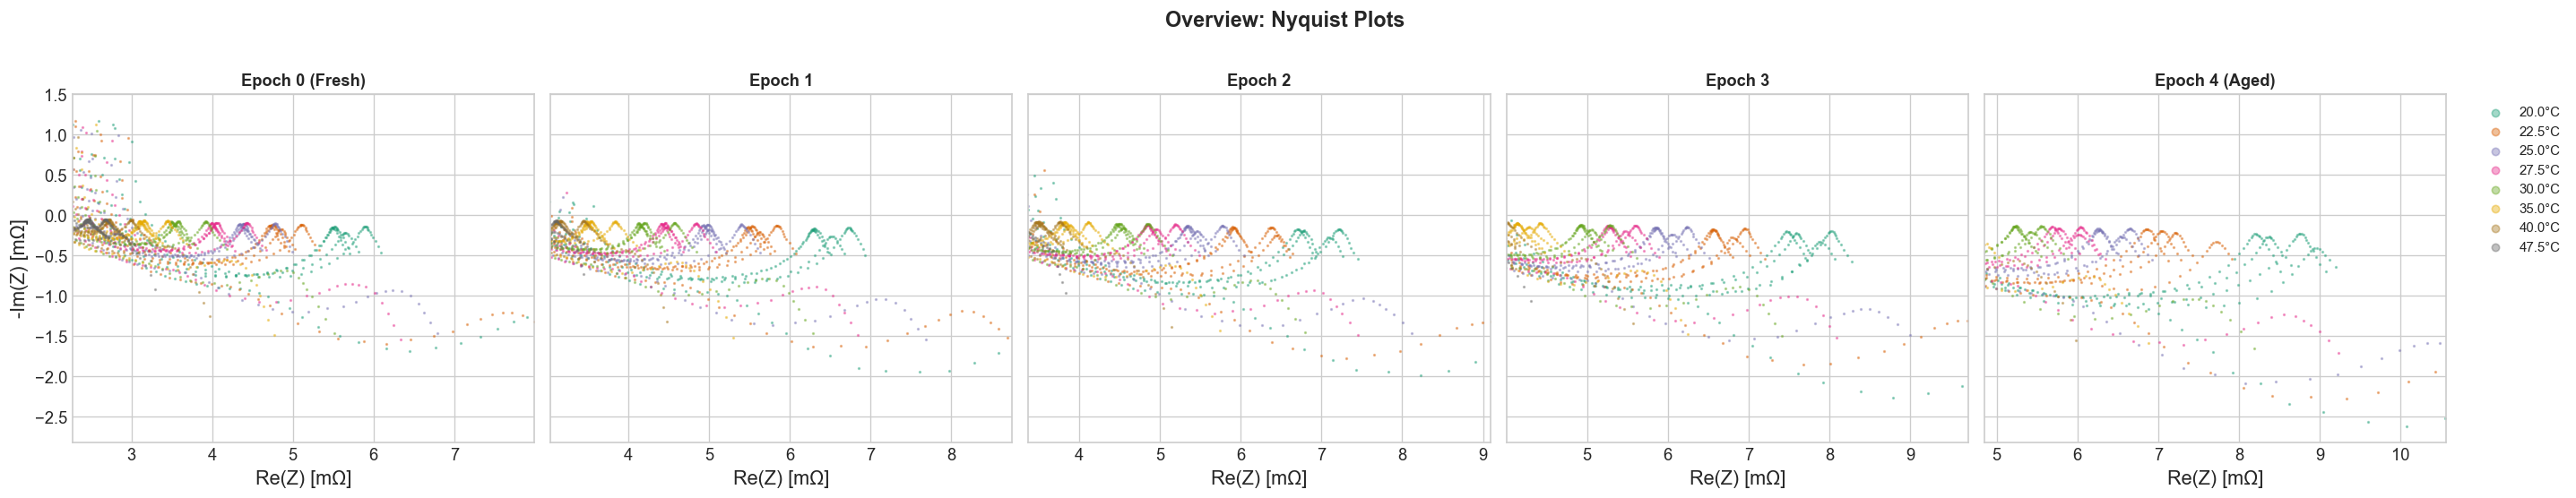

In [4]:
# 3.2 Nyquist plot overview by Epoch and Temperature
fig, axes = plt.subplots(1, 5, figsize=(24, 4.5), sharey=True)

for epoch in range(5):
    ax = axes[epoch]
    subset = df[df["Epoch"] == epoch]

    for temp in TEMPS_SORTED:
        mask = subset["Temperature"] == temp
        ax.scatter(
            subset.loc[mask, "Z_real"],
            -subset.loc[mask, "Z_imag"],
            s=1,
            alpha=0.4,
            color=TEMP_COLORS[temp],
            label=f"{temp}°C"
        )

    ax.set_xlabel("Re(Z) [mΩ]")
    
    if epoch == 0:
        ax.set_ylabel("-Im(Z) [mΩ]")

    ax.set_title(EPOCH_LABELS[epoch], fontsize=11, fontweight="bold")
    ax.set_aspect("equal", adjustable="datalim")

# Legend and title
axes[-1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    markerscale=5,
    fontsize=9
)

fig.suptitle(
    "Overview: Nyquist Plots",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

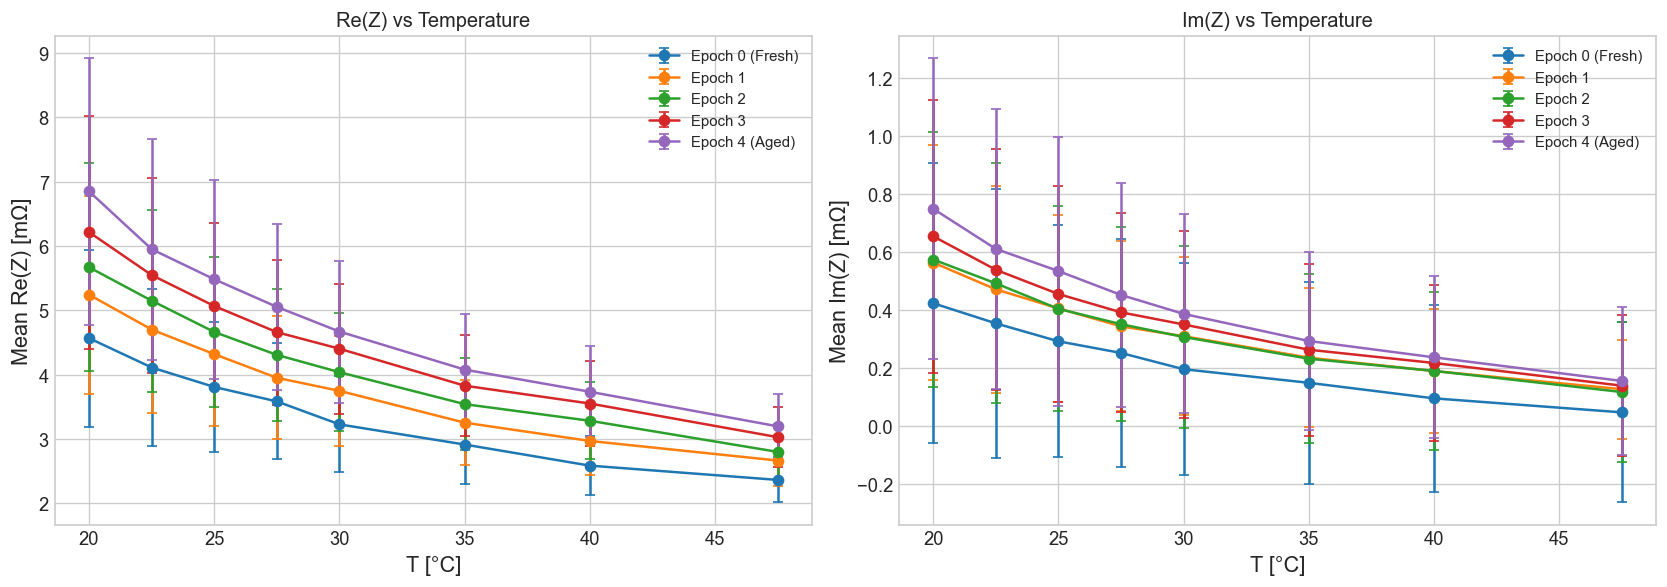

In [5]:
# 3.3 Impedance vs Temperature trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for epoch in range(5):
    subset = df[df["Epoch"] == epoch]

    for ax_idx, (col, label) in enumerate([("Z_real", "Re(Z)"), ("Z_imag", "Im(Z)")]):
        means = subset.groupby("Temperature")[col].mean()
        stds = subset.groupby("Temperature")[col].std()

        axes[ax_idx].errorbar(
            means.index,
            means.values,
            yerr=stds.values,
            marker="o",
            label=EPOCH_LABELS[epoch],
            capsize=3
        )

# Axis configuration
axes[0].set_xlabel("T [°C]")
axes[0].set_ylabel("Mean Re(Z) [mΩ]")
axes[0].set_title("Re(Z) vs Temperature")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("T [°C]")
axes[1].set_ylabel("Mean Im(Z) [mΩ]")
axes[1].set_title("Im(Z) vs Temperature")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# 4. Selection of the Combination to Exclude

> **Mode:**
> - `mode = 'random'` → randomly select an Epoch and Temperature  
> - `mode = 'manual'` → specify `MANUAL_EPOCH` and `MANUAL_TEMP` in the cells below  
>
> The selected combination is **completely removed** from the training set.  
> Its real data is used only for final validation.

In [15]:
# ╔════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION: Choose the selection mode                  ║
# ╚════════════════════════════════════════════════════════════╝

mode = 'random'           # 'random' or 'manual'

# If mode = 'manual', specify here:
MANUAL_EPOCH = 2          # Epoch to exclude (0, 1, 2, 3, 4)
MANUAL_TEMP  = 22.5       # Temperature to exclude (20.0, 22.5, 25.0, 27.5, 30.0, 35.0, 40.0, 47.5)

# ─────────────────────────────────────────────────────────────

if mode == 'manual':
    assert MANUAL_EPOCH in EPOCHS, f"Invalid Epoch {MANUAL_EPOCH}. Valid values: {EPOCHS}"
    assert MANUAL_TEMP in TEMPS_SORTED, f"Invalid Temperature {MANUAL_TEMP}. Valid values: {TEMPS_SORTED}"
    EXCLUDED_EPOCH = MANUAL_EPOCH
    EXCLUDED_TEMP = MANUAL_TEMP
    print("   MANUAL mode selected")
elif mode == 'random':
    np.random.seed(None)
    EXCLUDED_EPOCH = np.random.choice(EPOCHS)
    EXCLUDED_TEMP = np.random.choice(TEMPS_SORTED)
    print("   RANDOM mode selected")
else:
    raise ValueError(f"Mode '{mode}' not recognized. Use 'random' or 'manual'.")

print(f"   Excluded combination: Epoch {EXCLUDED_EPOCH}, {EXCLUDED_TEMP}°C")

# --- Split dataset ---
mask_excluded = (df['Epoch'] == EXCLUDED_EPOCH) & (df['Temperature'] == EXCLUDED_TEMP)
df_train = df[~mask_excluded].copy()
df_test = df[mask_excluded].copy()

print(f"   Training: {len(df_train):,} points "
      f"({df.groupby(['Epoch','Temperature']).ngroups - 1} combinations)")
print(f"   Test:     {len(df_test):,} points "
      f"(1 combination, {df_test['SOC'].nunique()} SOC × {len(df_test)//df_test['SOC'].nunique()} frequencies)")

   RANDOM mode selected
   Excluded combination: Epoch 4, 40.0°C
   Training: 9,560 points (39 combinations)
   Test:     245 points (1 combination, 5 SOC × 49 frequencies)


# 5. Generation of the 39 Nyquist Plots

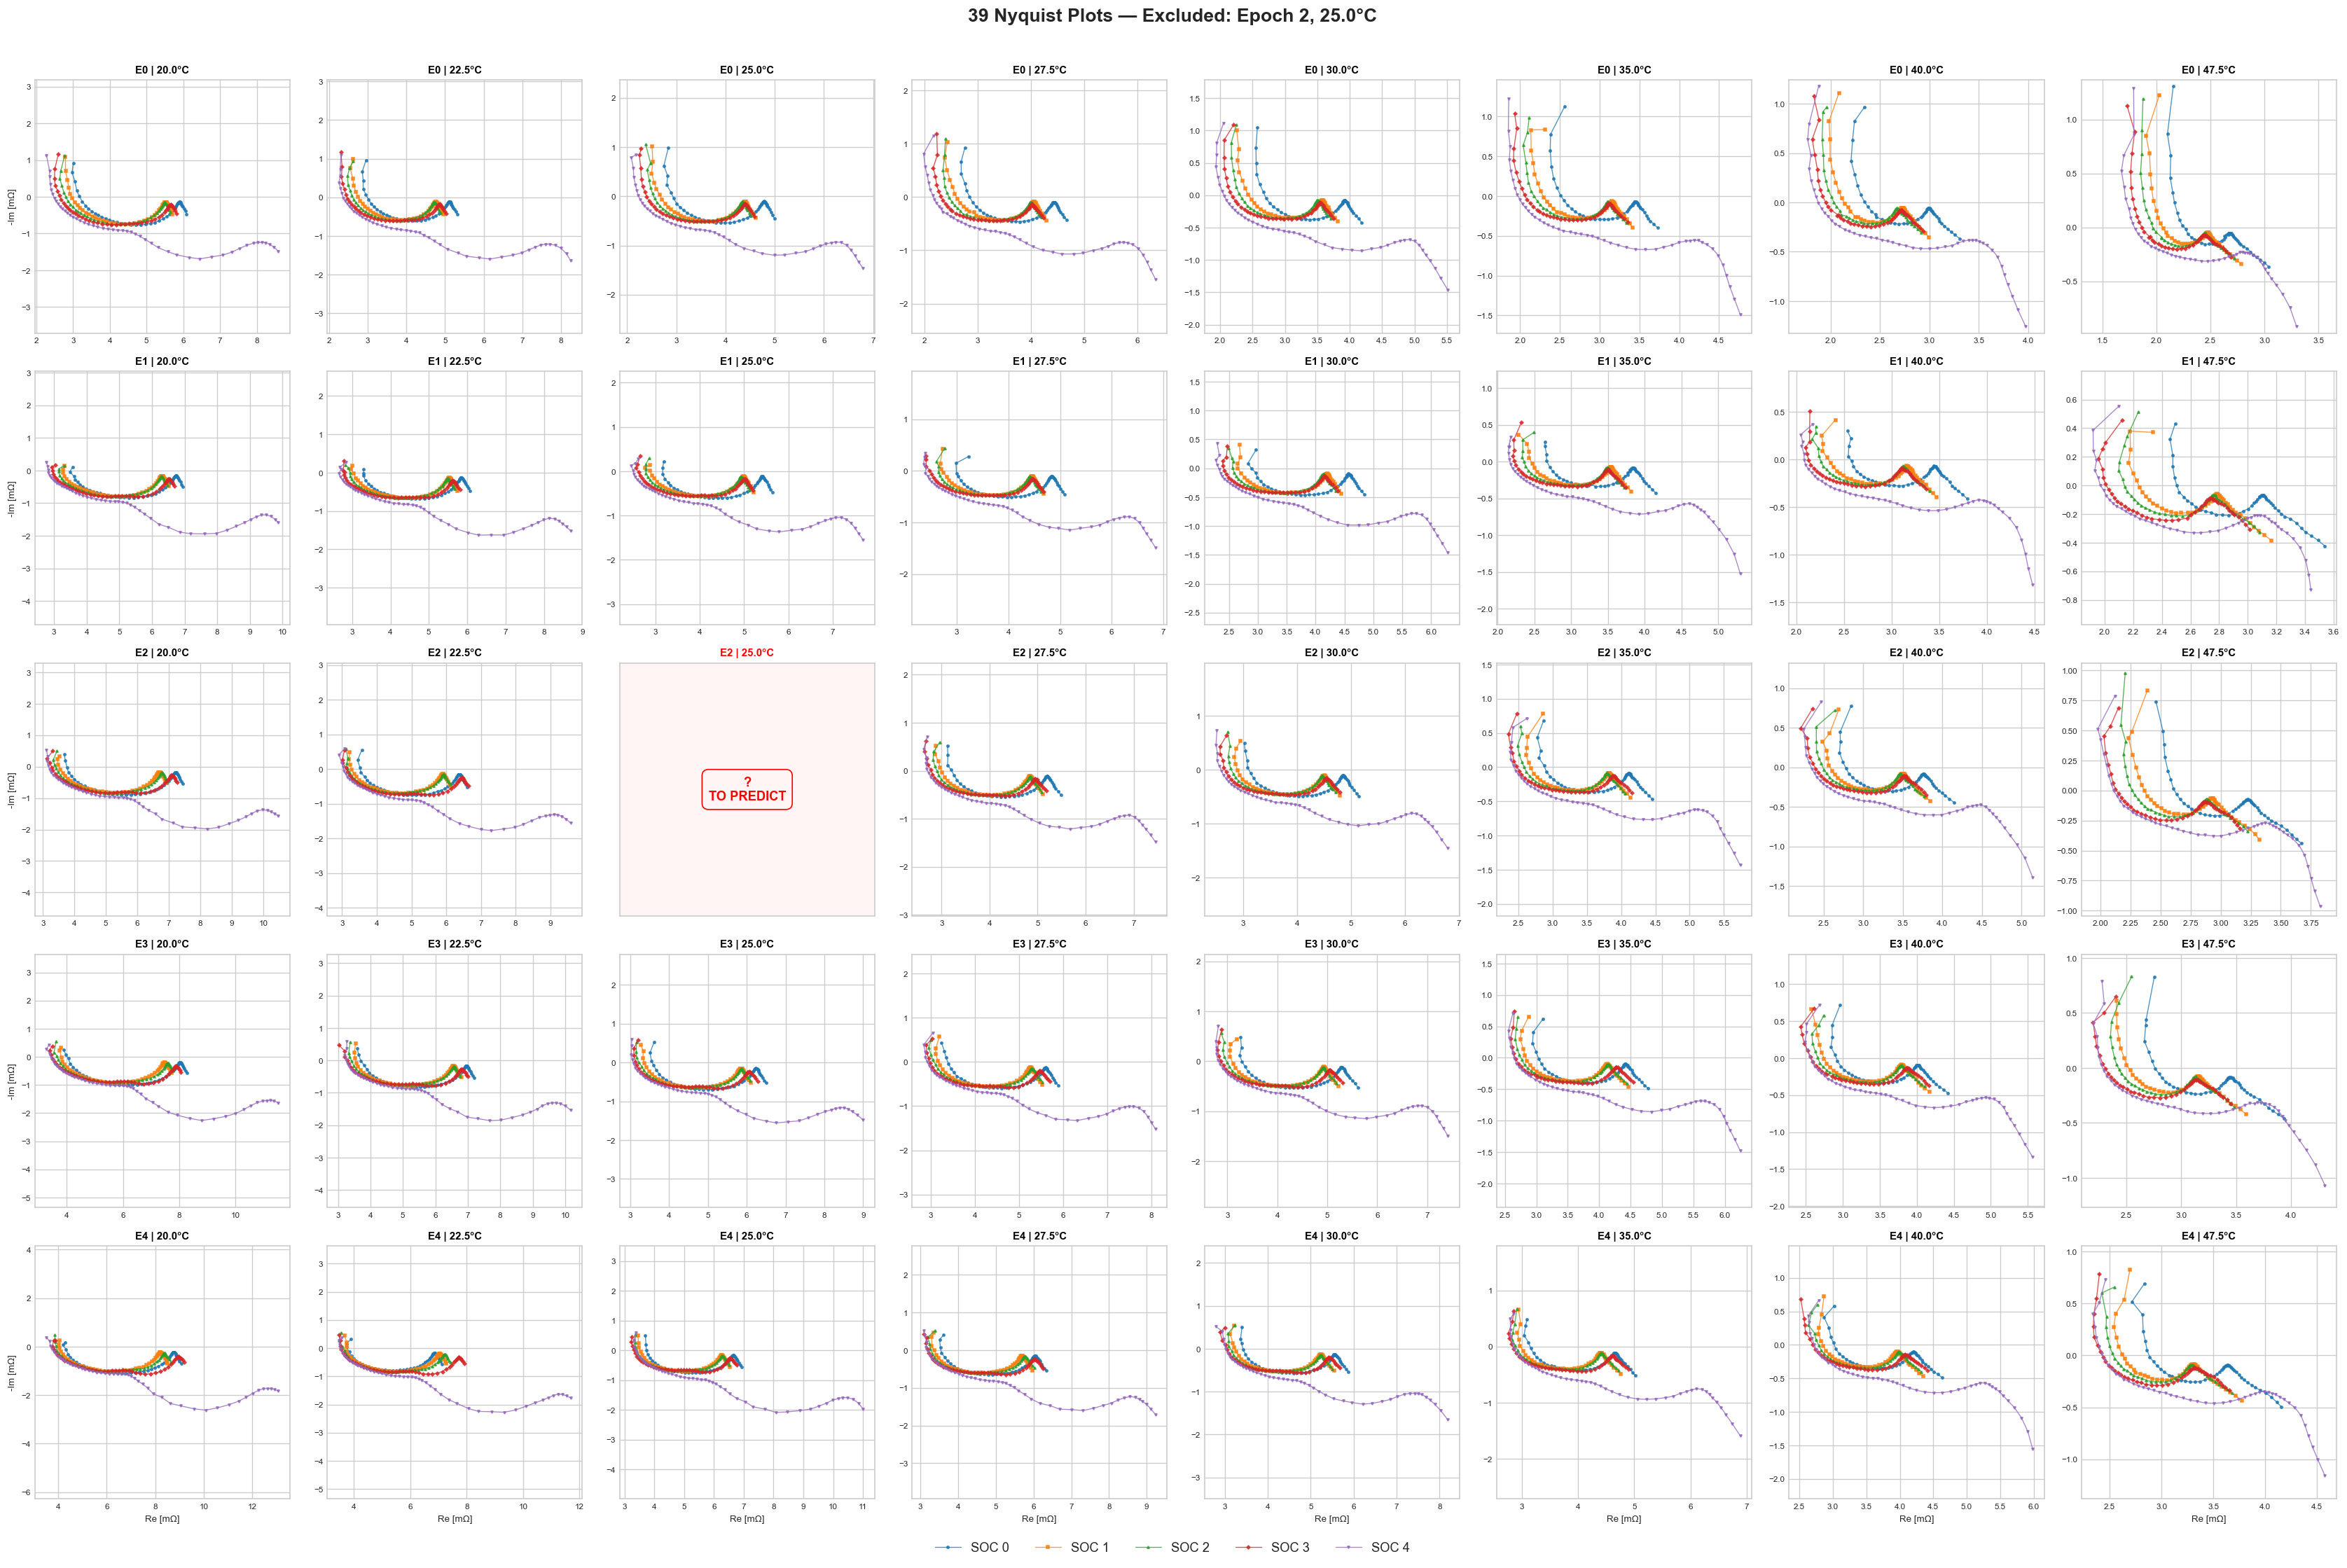

In [7]:
fig, axes = plt.subplots(5, 8, figsize=(28, 18))

for i, epoch in enumerate(EPOCHS):
    for j, temp in enumerate(TEMPS_SORTED):
        ax = axes[i][j]
        is_excluded = (epoch == EXCLUDED_EPOCH and temp == EXCLUDED_TEMP)

        if is_excluded:
            ax.text(
                0.5, 0.5, '?\nTO PREDICT',
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=11, fontweight='bold', color='red',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff5f5', edgecolor='red')
            )
            ax.set_facecolor('#fff5f5')
            ax.set_xticks([]); ax.set_yticks([])
        else:
            subset = df[(df['Epoch'] == epoch) & (df['Temperature'] == temp)]
            for soc in sorted(subset['SOC'].unique()):
                sd = subset[subset['SOC'] == soc]
                ax.plot(
                    sd['Z_real'], -sd['Z_imag'],
                    marker=SOC_MARKERS[soc],
                    markersize=2,
                    linewidth=0.8,
                    alpha=0.8,
                    label=f'SOC {soc}' if i == 0 and j == 0 else ''
                )
            ax.set_aspect('equal', adjustable='datalim')

        if i == 4: ax.set_xlabel('Re [mΩ]', fontsize=8)
        if j == 0: ax.set_ylabel('-Im [mΩ]', fontsize=8)
        title_color = 'red' if is_excluded else 'black'
        ax.set_title(f'E{epoch} | {temp}°C', fontsize=9, fontweight='bold', color=title_color)
        ax.tick_params(labelsize=7)

# Create legend
handles, labels = None, None
for ax_row in axes:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        if h: 
            handles, labels = h[:5], [f'SOC {i}' for i in range(5)]
            break
    if handles: break

if handles:
    fig.legend(
        handles, labels,
        loc='lower center',
        ncol=5,
        fontsize=11,
        bbox_to_anchor=(0.5, -0.02)
    )

fig.suptitle(
    f'39 Nyquist Plots — Excluded: Epoch {EXCLUDED_EPOCH}, {EXCLUDED_TEMP}°C',
    fontsize=16, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

# 6. Feature Engineering

In [8]:
def build_features(data):
    """Costruisce la matrice di features dal DataFrame."""
    X = pd.DataFrame({
        'Epoch':       data['Epoch'].values,
        'Temperature': data['Temperature'].values,
        'SOC':         data['SOC'].values,
        'Frequency':   data['Frequency'].values,
        'log_Freq':    np.log10(data['Frequency'].values),
        'Epoch_x_Temp': data['Epoch'].values * data['Temperature'].values,
        'SOC_x_Temp':   data['SOC'].values * data['Temperature'].values,
        'SOC_x_Epoch':  data['SOC'].values * data['Epoch'].values,
        'inv_Temp':     1.0 / (data['Temperature'].values + 273.15),
    })
    return X

# Costruzione features
X_train = build_features(df_train)
y_train = df_train[['Z_real', 'Z_imag']].values
X_test = build_features(df_test)
y_test = df_test[['Z_real', 'Z_imag']].values

# Standardizzazione
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)

print(f"Features ({X_train.shape[1]}): {list(X_train.columns)}")

Features (9): ['Epoch', 'Temperature', 'SOC', 'Frequency', 'log_Freq', 'Epoch_x_Temp', 'SOC_x_Temp', 'SOC_x_Epoch', 'inv_Temp']


# 7. Multi-Model Training

> Confrontiamo 6 modelli di complessità crescente:
>
> | Modello | Tipo | Caratteristica |
> |---|---|---|
> | Ridge Regression | Lineare | Baseline con regolarizzazione L2 |
> | Random Forest | Ensemble (bagging) | Alberi decisionali con bootstrap |
> | Gradient Boosting | Ensemble (boosting) | Correzione iterativa degli errori |
> | K-Nearest Neighbors | Instance-based | Predizione per similarità locale |
> | Bagging (Ridge) | Ensemble (bagging) | Riduzione varianza su modello lineare |

In [9]:
# --- DEFINE MODELS ---
models = {
    "Ridge Regression": MultiOutputRegressor(Ridge(alpha=1.0)),
    "Random Forest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    ),
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        )
    ),
    "K-Nearest Neighbors": MultiOutputRegressor(
        KNeighborsRegressor(n_neighbors=10, weights="distance")
    ),
    "Bagging (Ridge)": MultiOutputRegressor(
        BaggingRegressor(
            estimator=Ridge(alpha=1.0),
            n_estimators=30,
            max_samples=0.8,
            random_state=42
        )
    ),
}

# --- TRAINING AND EVALUATION ---
results = []
predictions = {}

print("=== TRAINING AND EVALUATION ===\n")
print(f"{'Model':<25s} {'R²':>8s} {'MSE':>10s} {'MAE':>8s} {'Time':>7s}")
print("─" * 62)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_s, y_train_s)
    y_pred_s = model.predict(X_test_s)
    y_pred = scaler_y.inverse_transform(y_pred_s)
    dt = time.time() - t0

    predictions[name] = y_pred

    # Metrics per component
    mse_r = mean_squared_error(y_test[:, 0], y_pred[:, 0])
    mse_i = mean_squared_error(y_test[:, 1], y_pred[:, 1])
    mae_r = mean_absolute_error(y_test[:, 0], y_pred[:, 0])
    mae_i = mean_absolute_error(y_test[:, 1], y_pred[:, 1])
    r2_r = r2_score(y_test[:, 0], y_pred[:, 0])
    r2_i = r2_score(y_test[:, 1], y_pred[:, 1])

    # Aggregate results
    results.append({
        "Model": name,
        "MSE_total": (mse_r + mse_i) / 2,
        "MAE_total": (mae_r + mae_i) / 2,
        "R2_total": (r2_r + r2_i) / 2,
        "R2_real": r2_r,
        "R2_imag": r2_i,
        "Time_s": dt
    })

    print(f"{name:<25s} {(r2_r+r2_i)/2:>8.4f} "
          f"{(mse_r+mse_i)/2:>10.6f} "
          f"{(mae_r+mae_i)/2:>8.4f} "
          f"{dt:>6.1f}s")

# Summary
results_df = pd.DataFrame(results).sort_values("MSE_total")
best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest model: {best_model_name} "
      f"(R²={results_df.iloc[0]['R2_total']:.4f})")

=== TRAINING AND EVALUATION ===

Model                           R²        MSE      MAE    Time
──────────────────────────────────────────────────────────────
Ridge Regression            0.6684   0.164146   0.2880    0.0s
Random Forest               0.9641   0.041995   0.1509    0.5s
Gradient Boosting           0.9885   0.009674   0.0612    1.4s
K-Nearest Neighbors         0.9885   0.007083   0.0515    0.0s
Bagging (Ridge)             0.6688   0.163889   0.2879    0.1s

Best model: K-Nearest Neighbors (R²=0.9885)


# 8. Model Comparison

In [10]:
# 8.1 Summary Table
print("=== RANKING (by MSE) ===\n")

display_df = results_df[['Model','MSE_total','MAE_total','R2_total','R2_real','R2_imag','Time_s']].copy()
display_df.columns = ['Model','MSE','MAE','R²','R²(Re)','R²(Im)','Time(s)']

print(display_df.to_string(index=False, float_format='{:.4f}'.format))

=== RANKING (by MSE) ===

              Model    MSE    MAE     R²  R²(Re)  R²(Im)  Time(s)
K-Nearest Neighbors 0.0071 0.0515 0.9885  0.9908  0.9861   0.0066
  Gradient Boosting 0.0097 0.0612 0.9885  0.9866  0.9904   1.4252
      Random Forest 0.0420 0.1509 0.9641  0.9391  0.9890   0.4934
    Bagging (Ridge) 0.1639 0.2879 0.6688  0.8010  0.5366   0.0555
   Ridge Regression 0.1641 0.2880 0.6684  0.8007  0.5361   0.0030


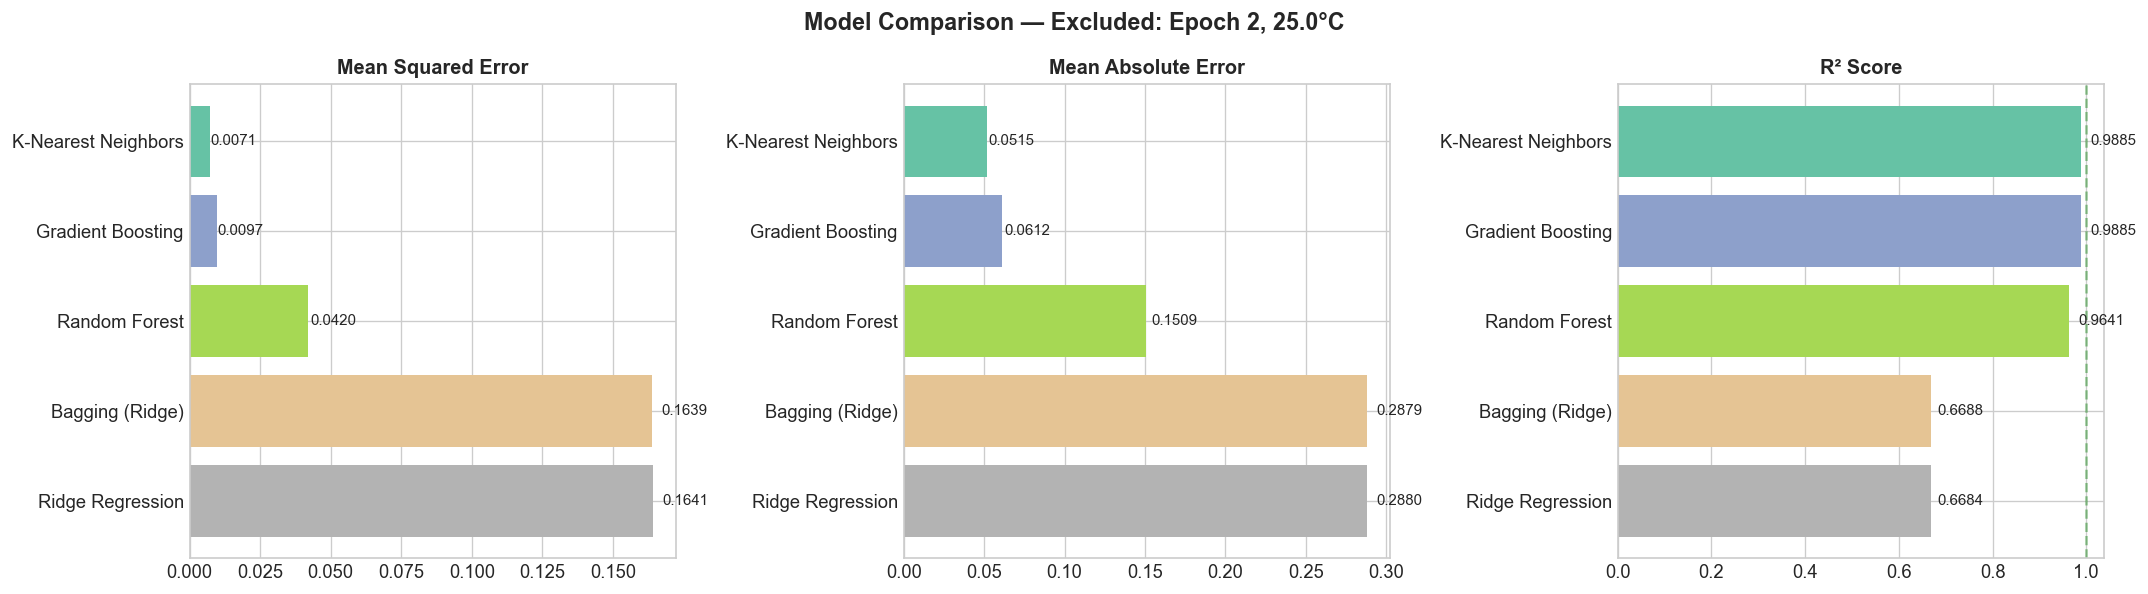

In [11]:
# 8.2 Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

metrics = [
    ('MSE_total', 'Mean Squared Error'),
    ('MAE_total', 'Mean Absolute Error'),
    ('R2_total', 'R² Score')
]

for ax, (col, title) in zip(axes, metrics):
    vals = results_df[col].values
    bars = ax.barh(results_df['Model'].values, vals, color=colors)
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_width() * 1.02,
            bar.get_y() + bar.get_height()/2,
            f'{v:.4f}',
            va='center',
            fontsize=9
        )
    
    if col == 'R2_total':
        ax.axvline(x=1.0, color='green', linestyle='--', alpha=0.4)

fig.suptitle(
    f'Model Comparison — Excluded: Epoch {EXCLUDED_EPOCH}, {EXCLUDED_TEMP}°C',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# 9. Prediction Visualization

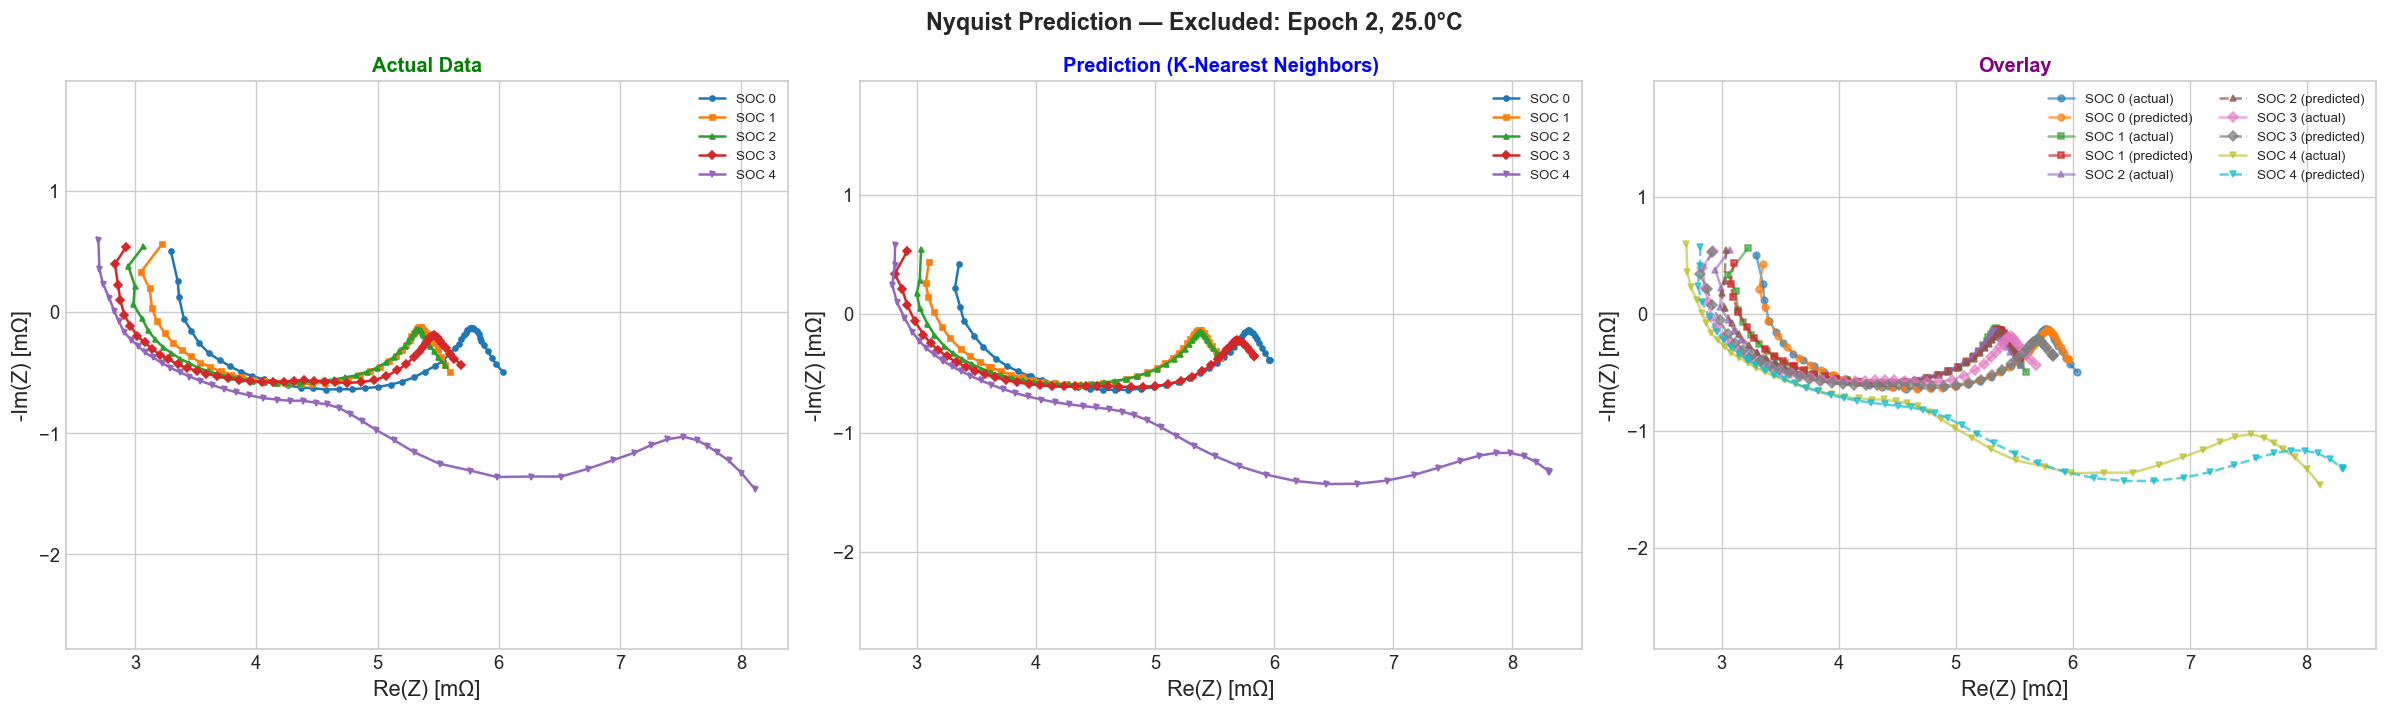

In [12]:
# 9.1 Best Model: Actual vs Predicted vs Overlay
best_pred = predictions[best_model_name]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

soc_list = sorted(df_test['SOC'].unique())
for soc in soc_list:
    mask = df_test['SOC'].values == soc
    # Actual data
    axes[0].plot(
        y_test[mask, 0], -y_test[mask, 1],
        marker=SOC_MARKERS[soc], markersize=3, label=f'SOC {soc}'
    )
    # Predicted data
    axes[1].plot(
        best_pred[mask, 0], -best_pred[mask, 1],
        marker=SOC_MARKERS[soc], markersize=3, label=f'SOC {soc}'
    )
    # Overlay
    axes[2].plot(
        y_test[mask, 0], -y_test[mask, 1],
        marker=SOC_MARKERS[soc], markersize=4, alpha=0.6,
        linewidth=1.5, label=f'SOC {soc} (actual)'
    )
    axes[2].plot(
        best_pred[mask, 0], -best_pred[mask, 1],
        marker=SOC_MARKERS[soc], markersize=4,
        linestyle='--', alpha=0.7, linewidth=1.5, label=f'SOC {soc} (predicted)'
    )

# Configure axes
for ax, title, color in zip(
    axes,
    ['Actual Data', f'Prediction ({best_model_name})', 'Overlay'],
    ['green', 'blue', 'purple']
):
    ax.set_xlabel('Re(Z) [mΩ]')
    ax.set_ylabel('-Im(Z) [mΩ]')
    ax.set_title(title, fontweight='bold', color=color)
    ax.legend(fontsize=8, ncol=2 if 'Overlay' in title else 1)
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle(
    f'Nyquist Prediction — Excluded: Epoch {EXCLUDED_EPOCH}, {EXCLUDED_TEMP}°C',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.show()

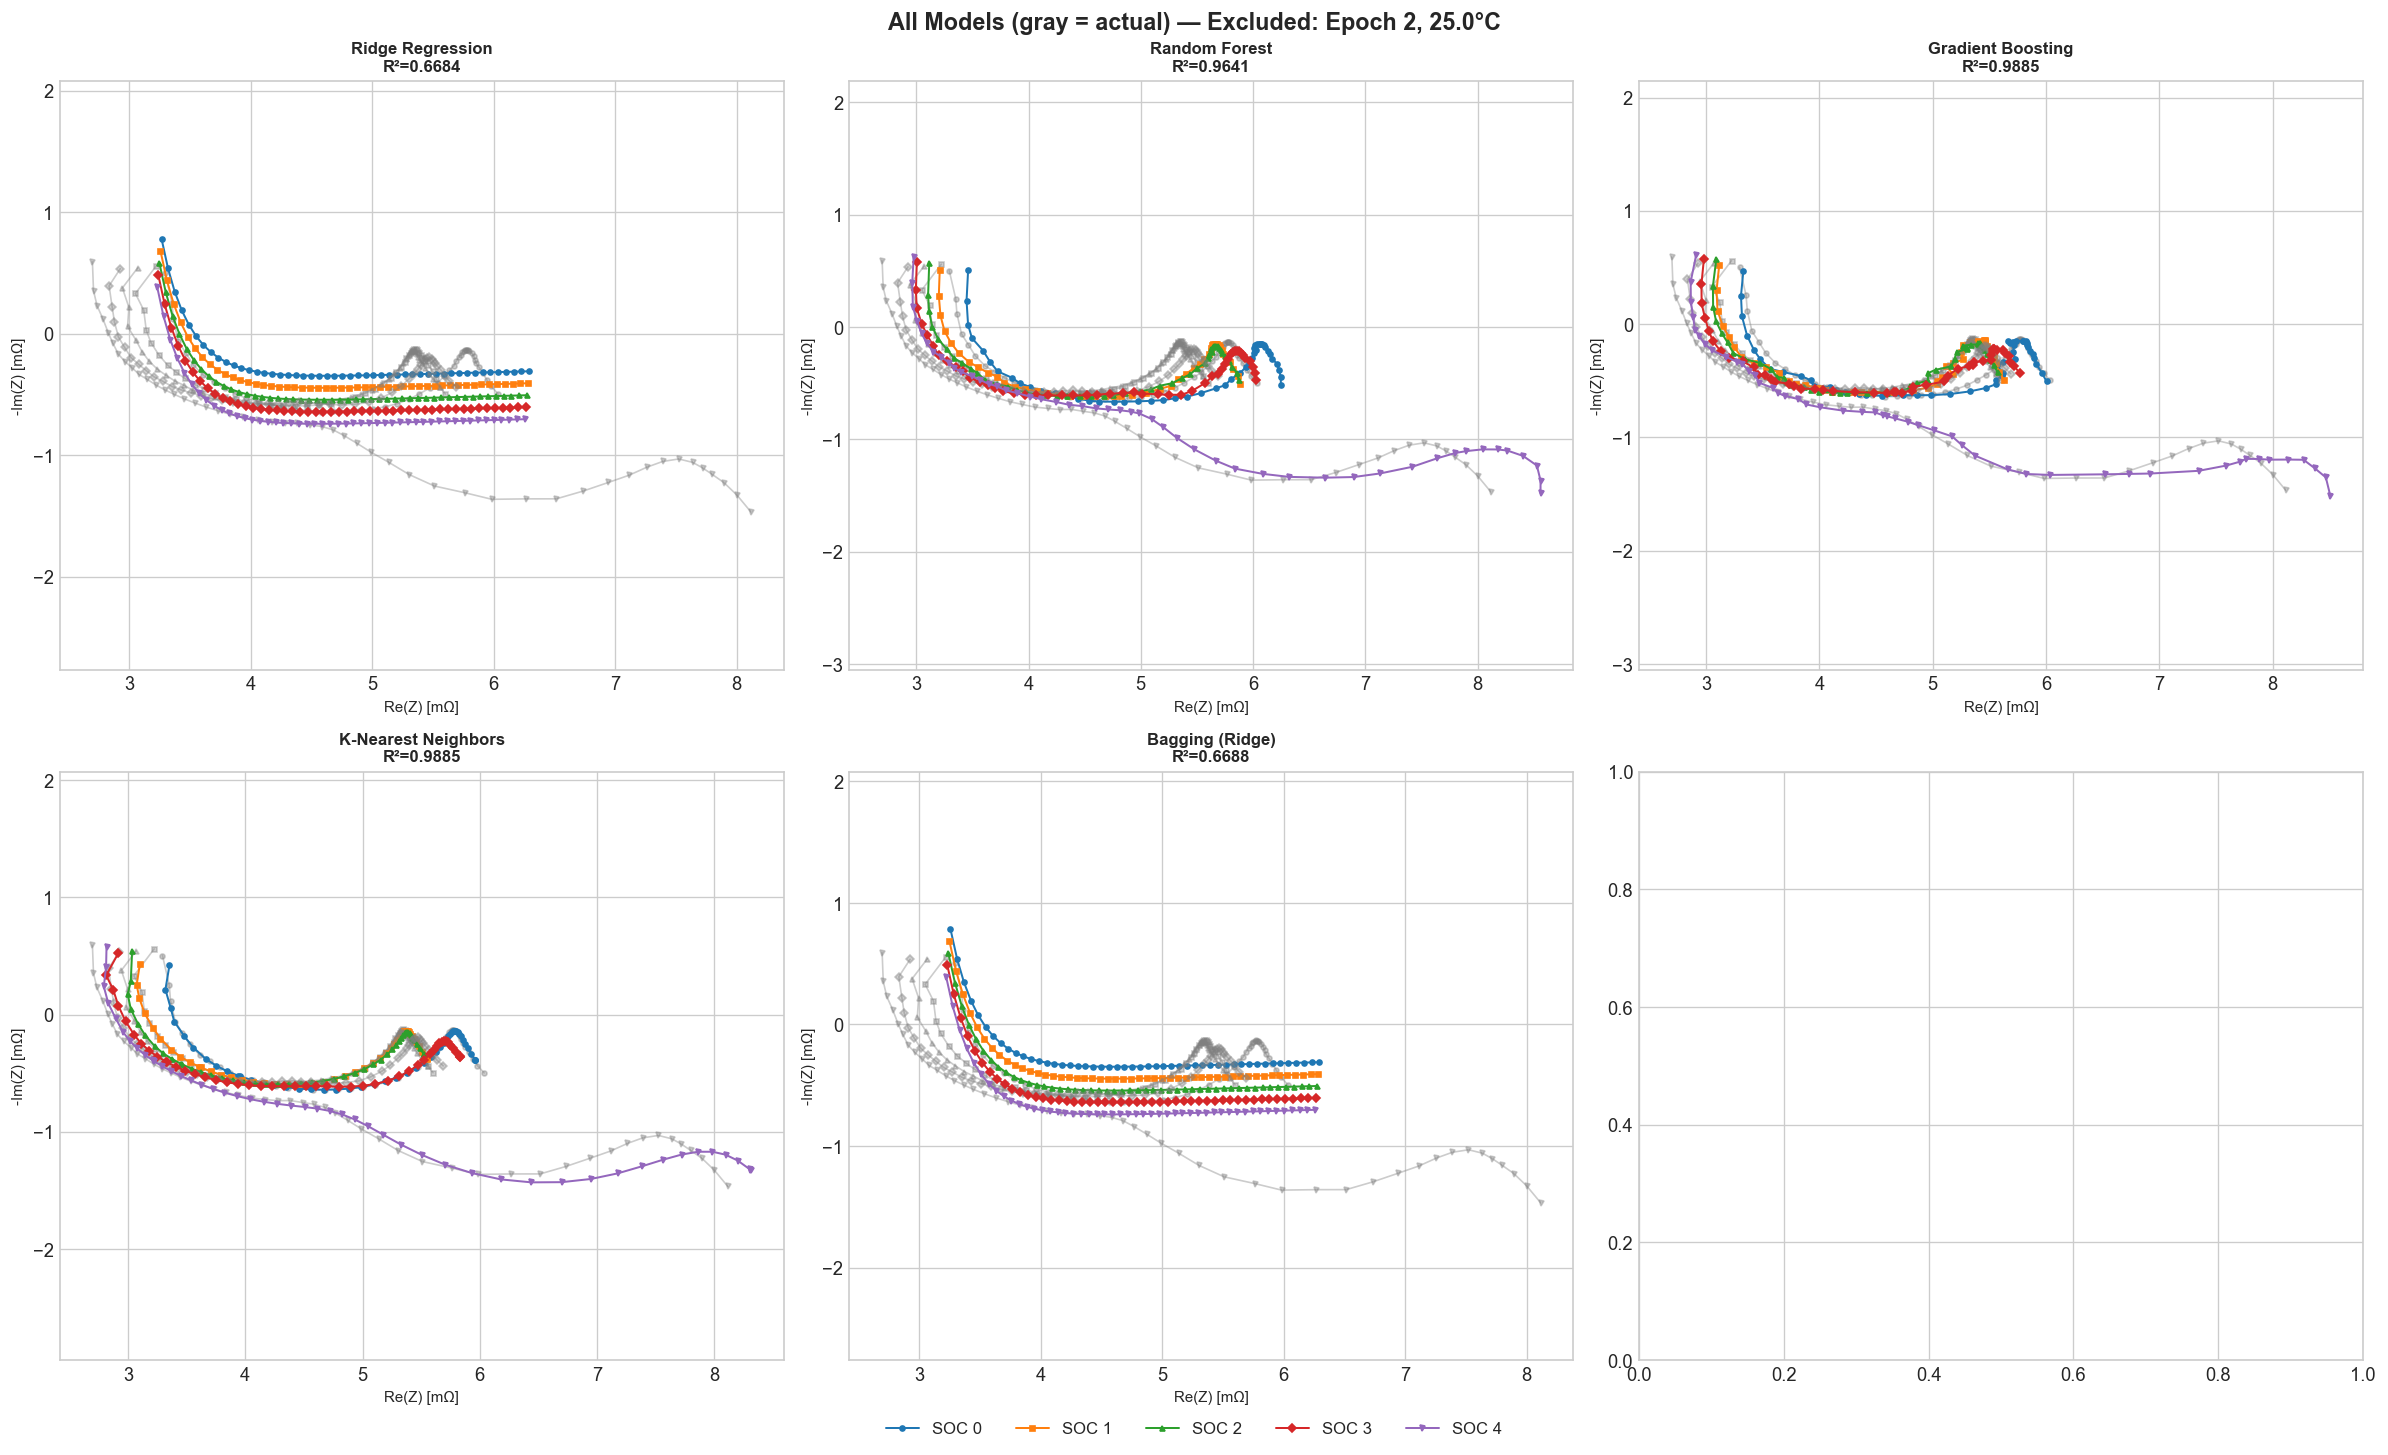

In [13]:
# 9.2 All Models
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

for idx, (name, pred) in enumerate(predictions.items()):
    ax = axes_flat[idx]
    for soc in soc_list:
        mask = df_test['SOC'].values == soc
        # Actual data in gray
        ax.plot(
            y_test[mask, 0], -y_test[mask, 1],
            marker=SOC_MARKERS[soc], markersize=3,
            alpha=0.4, color='gray', linewidth=1
        )
        # Predicted data
        ax.plot(
            pred[mask, 0], -pred[mask, 1],
            marker=SOC_MARKERS[soc], markersize=3,
            linewidth=1.2, label=f'SOC {soc}'
        )
    r2 = results_df[results_df['Model'] == name]['R2_total'].values[0]
    ax.set_title(f'{name}\nR²={r2:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Re(Z) [mΩ]', fontsize=9)
    ax.set_ylabel('-Im(Z) [mΩ]', fontsize=9)
    ax.set_aspect('equal', adjustable='datalim')

# Shared legend
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=5,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    f'All Models (gray = actual) — Excluded: Epoch {EXCLUDED_EPOCH}, {EXCLUDED_TEMP}°C',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.show()

# 11. Hyperparameter Tuning


In [14]:
print(f"=== HYPERPARAMETER TUNING: {best_model_name} ===\n")

# Parameter grid per model
tuning_configs = {
    "Random Forest": {
        "model": MultiOutputRegressor(RandomForestRegressor(random_state=42, n_jobs=-1)),
        "params": {
            "estimator__n_estimators": [100, 200],
            "estimator__max_depth": [10, 20],
            "estimator__min_samples_leaf": [1, 3]
        }
    },
    "Gradient Boosting": {
        "model": MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
        "params": {
            "estimator__n_estimators": [100, 200],
            "estimator__max_depth": [3, 6],
            "estimator__learning_rate": [0.05, 0.1]
        }
    },
    "K-Nearest Neighbors": {
        "model": MultiOutputRegressor(KNeighborsRegressor()),
        "params": {
            "estimator__n_neighbors": [3, 5, 10, 15, 25],
            "estimator__weights": ["uniform", "distance"]
        }
    },
    "Bagging (Ridge)": {
        "model": MultiOutputRegressor(BaggingRegressor(estimator=Ridge(alpha=1.0), random_state=42)),
        "params": {
            "estimator__n_estimators": [20, 30, 50],
            "estimator__max_samples": [0.6, 0.8, 1.0]
        }
    },
    "Ridge Regression": {
        "model": MultiOutputRegressor(Ridge()),
        "params": {
            "estimator__alpha": [0.01, 0.1, 1, 10, 100]
        }
    },
}

config = tuning_configs.get(best_model_name)
if config:
    search = GridSearchCV(
        config["model"], config["params"], cv=3,
        scoring="neg_mean_squared_error", n_jobs=-1
    )
    search.fit(X_train_s, y_train_s)

    print(f"   Best params: {search.best_params_}")

    y_pred_tuned = scaler_y.inverse_transform(search.best_estimator_.predict(X_test_s))
    mse_tuned = (
        mean_squared_error(y_test[:,0], y_pred_tuned[:,0]) +
        mean_squared_error(y_test[:,1], y_pred_tuned[:,1])
    ) / 2
    r2_tuned = (
        r2_score(y_test[:,0], y_pred_tuned[:,0]) +
        r2_score(y_test[:,1], y_pred_tuned[:,1])
    ) / 2
    mse_orig = results_df.iloc[0]["MSE_total"]

    print(f"   Original MSE: {mse_orig:.6f} → Tuned MSE: {mse_tuned:.6f}")
    print(f"   Tuned R²: {r2_tuned:.4f}")

    if mse_tuned < mse_orig:
        improvement = (mse_orig - mse_tuned) / mse_orig * 100
        print(f"      Improvement: {improvement:.1f}%")
        FINAL_PRED = y_pred_tuned
        FINAL_MODEL = f"Tuned {best_model_name}"
    else:
        print(f"   ℹ️ No improvement. Using original model.")
        FINAL_PRED = predictions[best_model_name]
        FINAL_MODEL = best_model_name
else:
    FINAL_PRED = predictions[best_model_name]
    FINAL_MODEL = best_model_name

=== HYPERPARAMETER TUNING: K-Nearest Neighbors ===

   Best params: {'estimator__n_neighbors': 3, 'estimator__weights': 'distance'}
   Original MSE: 0.007083 → Tuned MSE: 0.005005
   Tuned R²: 0.9945
      Improvement: 29.3%
